<a href="https://colab.research.google.com/github/lucianoyllarreta/CLASE_CIENCIA_DATOS_I/blob/main/LOS%204%20FANT%C3%81STICOS/%20SCORING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
upload  = files.upload()

Saving df_final.csv to df_final.csv


In [ ]:
import pandas as pd
df = pd.read_csv('df_final.csv')

In [ ]:
df

,country,year,iso_code,population,gdp,gdp_per_capita,income_top10,income_bottom50,Female_15+,Male_15+,Total_15+,brecha de desempleo de genero
0,Afghanistan,1991,AFG,12238879,1.204736e+10,984.35,41.94,17.17,10.470,7.460,7.972,-3.010
1,Afghanistan,1992,AFG,13278983,1.267754e+10,954.71,41.94,17.17,10.456,7.448,7.958,-3.008
2,Afghanistan,1993,AFG,14943175,9.834582e+09,658.13,41.94,17.17,10.403,7.402,7.908,-3.001
3,Afghanistan,1994,AFG,16250800,7.919856e+09,487.35,41.94,17.17,10.380,7.382,7.883,-2.998
4,Afghanistan,1995,AFG,17065837,1.230753e+10,721.18,41.94,17.17,10.369,7.371,7.868,-2.998
...,...,...,...,...,...,...,...,...,...,...,...,...
5394,Zimbabwe,2020,ZWE,15526887,2.317871e+10,1492.81,58.95,9.23,8.491,8.744,8.617,0.253
5395,Zimbabwe,2021,ZWE,15797220,2.514009e+10,1591.42,58.95,9.23,9.858,9.221,9.540,-0.637
5396,Zimbabwe,2022,ZWE,16069061,2.590159e+10,1611.89,58.95,9.23,10.562,9.615,10.087,-0.947
5397,Zimbabwe,2023,ZWE,16340829,NaN,NaN,58.95,9.23,9.516,9.182,9.348,-0.334


In [ ]:
print("PROPUESTA DE NUEVOS KPIs ESTRATÉGICOS")
print("=" * 60)

# 1. KPI: Índice de Equidad de Oportunidades (IEO)
df['IEO'] = df['norm_gdp'] * df['norm_bci']

# 2. KPI: Coeficiente de Fragilidad Laboral de Género (CFLG)
df['CFLG'] = df['brecha de desempleo de genero'] / (df['Total_15+'] + 0.1)

# 3. KPI: Intensidad de Capital Humano (ICH)
df['ICH'] = df['gdp'] / (df['Total_15+'] * df['population'] / 100)

# Clarificamos que estos son promedios de TODA la base de datos
print(f"  ✔ IEO (Equidad)       - Promedio GLOBAL: {df['IEO'].mean():.4f}")
print(f"  ✔ CFLG (Género)       - Promedio GLOBAL: {df['CFLG'].mean():.4f}")
print(f"  ✔ ICH (Productividad) - Promedio GLOBAL: {df['ICH'].mean():.2f}")

# --- Interpretación específica para Argentina ---
print("\nINTERPRETACIÓN DE RESULTADOS ESPECÍFICOS (ARGENTINA - ÚLTIMO DATO VÁLIDO)")
print("-" * 60)
# Buscamos el último año donde Argentina tenga datos completos de estos KPIs (usualmente 2022)
latest_arg = df[df['country'] == 'Argentina'].dropna(subset=['IEO']).iloc[-1]

interpretations = [
    (f"IEO ({latest_arg['IEO']:.3f}):", "Refleja la sinergia entre riqueza y distribución en Argentina. Un valor bajo sugiere que el crecimiento no llega equitativamente."),
    (f"CFLG ({latest_arg['CFLG']:.3f}):", "Mide la vulnerabilidad de las mujeres en el mercado laboral argentino. Si es negativo, la brecha es menor al promedio histórico."),
    (f"ICH (${latest_arg['ICH']:,.2f}):", "Representa la productividad teórica por cada trabajador potencial en Argentina. Es clave para medir la eficiencia del capital humano.")
]

for kpi, text in interpretations:
    print(f"{kpi:<20} {text}")

print(f"\nNota: Los valores de Argentina corresponden al año {int(latest_arg['year'])}.")
print("\nÚltimos registros en tabla:")
display(df[df['country'] == 'Argentina'][['year', 'IEO', 'CFLG', 'ICH']].tail(3))

PROPUESTA DE NUEVOS KPIs ESTRATÉGICOS
  ✔ IEO (Equidad)       - Promedio GLOBAL: 0.0780
  ✔ CFLG (Género)       - Promedio GLOBAL: -0.2419
  ✔ ICH (Productividad) - Promedio GLOBAL: 569364.83

INTERPRETACIÓN DE RESULTADOS ESPECÍFICOS (ARGENTINA - ÚLTIMO DATO VÁLIDO)
------------------------------------------------------------
IEO (0.101):         Refleja la sinergia entre riqueza y distribución en Argentina. Un valor bajo sugiere que el crecimiento no llega equitativamente.
CFLG (-0.223):       Mide la vulnerabilidad de las mujeres en el mercado laboral argentino. Si es negativo, la brecha es menor al promedio histórico.
ICH ($276,670.61):   Representa la productividad teórica por cada trabajador potencial en Argentina. Es clave para medir la eficiencia del capital humano.

Nota: Los valores de Argentina corresponden al año 2022.

Últimos registros en tabla:


,year,IEO,CFLG,ICH
167,2022,0.100844,-0.222592,276670.610777
168,2023,NaN,-0.184645,NaN
169,2024,NaN,-0.184276,NaN


In [ ]:
print("PASO 4 — Construcción de KPIs")
print("=" * 60)

# KPI 1: Brecha de Concentración de Ingresos (BCI)
# Cuanto más alta → más desigualdad → peor score
df["BCI"] = df["income_top10"] / df["income_bottom50"]



print("  ✔ BCI creado             (income_top10 / income_bottom50)")
print(f"\n  BCI promedio global:  {df['BCI'].mean():.2f}")

PASO 4 — Construcción de KPIs
  ✔ BCI creado             (income_top10 / income_bottom50)

  BCI promedio global:  3.82


In [ ]:
# Normalizar — nota la INVERSIÓN de lógica para variables donde
# "más alto = peor":
#   gdp_per_capita  → más alto = mejor  → sin invertir
#   unemp_total_15  → más alto = peor   → invertir (1 - norm)
#   BCI             → más alto = peor   → invertir (1 - norm)
print("PASO 5 — Normalización Min-Max (escala global histórica)")
print("=" * 60)

def minmax(series):
    """Normaliza una serie al rango [0, 1]."""
    min_v, max_v = series.min(), series.max()
    if max_v == min_v:
        return pd.Series(0.5, index=series.index)
    return (series - min_v) / (max_v - min_v)

df["norm_gdp"]    =       minmax(df["gdp_per_capita"])
df["norm_unemp"]  = 1   - minmax(df["Total_15+"])   # invertido
df["norm_bci"]    = 1   - minmax(df["BCI"])              # invertido

print("  ✔ norm_gdp     (mayor = mejor capacidad fiscal)")
print("  ✔ norm_unemp   (menor desempleo = mayor puntaje)")
print("  ✔ norm_bci     (menor concentración = mayor puntaje)")

PASO 5 — Normalización Min-Max (escala global histórica)
  ✔ norm_gdp     (mayor = mejor capacidad fiscal)
  ✔ norm_unemp   (menor desempleo = mayor puntaje)
  ✔ norm_bci     (menor concentración = mayor puntaje)


In [ ]:
# 6. CÁLCULO DEL ÍNDICE DE RESILIENCIA (0-100)
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("PASO 6 — Índice de Resiliencia Macro-Social (0–100)")
print("=" * 60)

PESO_ECONOMICO  = 0.50
PESO_LABORAL    = 0.30
PESO_EQUIDAD    = 0.20

df["score_resiliencia"] = (
    df["norm_gdp"]   * PESO_ECONOMICO  +
    df["norm_unemp"] * PESO_LABORAL    +
    df["norm_bci"]   * PESO_EQUIDAD
) * 100

# Redondear a 2 decimales
df["score_resiliencia"] = df["score_resiliencia"].round(2)

print(f"  Pesos: Económico={PESO_ECONOMICO*100:.0f}% | "
      f"Laboral={PESO_LABORAL*100:.0f}% | Equidad={PESO_EQUIDAD*100:.0f}%")
print(f"\n  Score global promedio: {df['score_resiliencia'].mean():.1f}")
print(f"  Score mínimo:          {df['score_resiliencia'].min():.1f}")
print(f"  Score máximo:          {df['score_resiliencia'].max():.1f}")


PASO 6 — Índice de Resiliencia Macro-Social (0–100)
  Pesos: Económico=50% | Laboral=30% | Equidad=20%

  Score global promedio: 45.4
  Score mínimo:          16.8
  Score máximo:          95.1


In [ ]:
print('Top 5 países ÚNICOS con los registros históricos más bajos de resiliencia:')
# Agrupar por país para obtener su peor momento histórico (mínimo score)
df_peores_unicos = df.groupby('country')[['year', 'score_resiliencia']].min().sort_values(by='score_resiliencia', ascending=True).head(5)
display(df_peores_unicos)

Top 5 países ÚNICOS con los registros históricos más bajos de resiliencia:


,year,score_resiliencia
country,,
Namibia,1991,16.84
South Africa,1991,17.80
North Macedonia,1991,20.58
Algeria,1991,24.82
Botswana,1991,25.08


In [ ]:
from IPython.display import display
top_5_gdp = df.sort_values(by='norm_gdp', ascending=False).head(5)
display(top_5_gdp[['country', 'year', 'norm_gdp']])

,country,year,norm_gdp
4065,Qatar,2011,1.000000
4066,Qatar,2012,0.994480
4067,Qatar,2013,0.984885
4068,Qatar,2014,0.950486
4069,Qatar,2015,0.909855


In [ ]:
print('Top 15 por norm_gdp:')
top_15_gdp = df.sort_values(by='norm_gdp', ascending=False).head(15)
display(top_15_gdp[['country', 'year', 'norm_gdp']])

Top 15 por norm_gdp:


,country,year,norm_gdp
4065,Qatar,2011,1.000000
4066,Qatar,2012,0.994480
4067,Qatar,2013,0.984885
4068,Qatar,2014,0.950486
4069,Qatar,2015,0.909855
4070,Qatar,2016,0.875585
4064,Qatar,2010,0.853473
4071,Qatar,2017,0.828149
4072,Qatar,2018,0.821833
4073,Qatar,2019,0.816595


In [ ]:
print('\nTop 15 por norm_unemp:')
top_15_unemp = df.sort_values(by='norm_unemp', ascending=False).head(15)
display(top_15_unemp[['country', 'year', 'norm_unemp']])


Top 15 por norm_unemp:


,country,year,norm_unemp
4073,Qatar,2019,1.000000
4072,Qatar,2018,0.999742
844,Cambodia,2019,0.999509
843,Cambodia,2018,0.999251
4077,Qatar,2023,0.999225
4076,Qatar,2022,0.999225
4078,Qatar,2024,0.999225
4074,Qatar,2020,0.998966
4071,Qatar,2017,0.998966
4075,Qatar,2021,0.998966


In [ ]:
print('\nTop 15 por norm_bci:')
top_15_bci = df.sort_values(by='norm_bci', ascending=False).head(15)
display(top_15_bci[['country', 'year', 'norm_bci']])


Top 15 por norm_bci:


,country,year,norm_bci
4487,Slovenia,1991,1.000000
3705,Norway,1991,0.999884
2210,Hungary,1991,0.998738
3706,Norway,1992,0.998568
4454,Slovakia,1992,0.998224
4488,Slovenia,1992,0.997392
2214,Hungary,1995,0.995735
4455,Slovakia,1993,0.995528
1735,Finland,1992,0.995136
4858,Tajikistan,1991,0.995033


In [ ]:
df_2020 = df[df['year'] == 2020]
display(df_2020[['country', 'score_resiliencia']])

,country,score_resiliencia
29,Afghanistan,40.13
63,Albania,43.43
97,Algeria,40.84
131,Angola,33.42
165,Argentina,43.01
...,...,...
5258,Uzbekistan,46.98
5292,Vanuatu,NaN
5326,Yemen,31.65
5360,Zambia,40.92


In [ ]:
print('Top 20 países con mejor score de resiliencia en 2020:')
top_20_best = df_2020.sort_values(by='score_resiliencia', ascending=False).head(20)
display(top_20_best[['country', 'score_resiliencia']])

Top 20 países con mejor score de resiliencia en 2020:


,country,score_resiliencia
4074,Qatar,84.75
3734,Norway,71.78
4448,Singapore,67.35
5190,United Arab Emirates,66.62
4853,Switzerland,64.44
2409,Ireland,61.57
3530,Netherlands,60.53
2952,Luxembourg,60.39
1933,Germany,59.63
2681,Kuwait,59.43


In [ ]:
print('\nTop 20 países con peor score de resiliencia en 2020:')
top_20_worst = df_2020.sort_values(by='score_resiliencia', ascending=True).head(20)
display(top_20_worst[['country', 'score_resiliencia']])


Top 20 países con peor score de resiliencia en 2020:


,country,score_resiliencia
4618,South Africa,21.40
1389,Djibouti,26.71
3462,Namibia,27.96
1151,Congo,29.59
4176,Saint Lucia,30.42
675,Botswana,31.57
5326,Yemen,31.65
1083,Colombia,32.32
1185,Costa Rica,32.42
2816,Lesotho,33.16


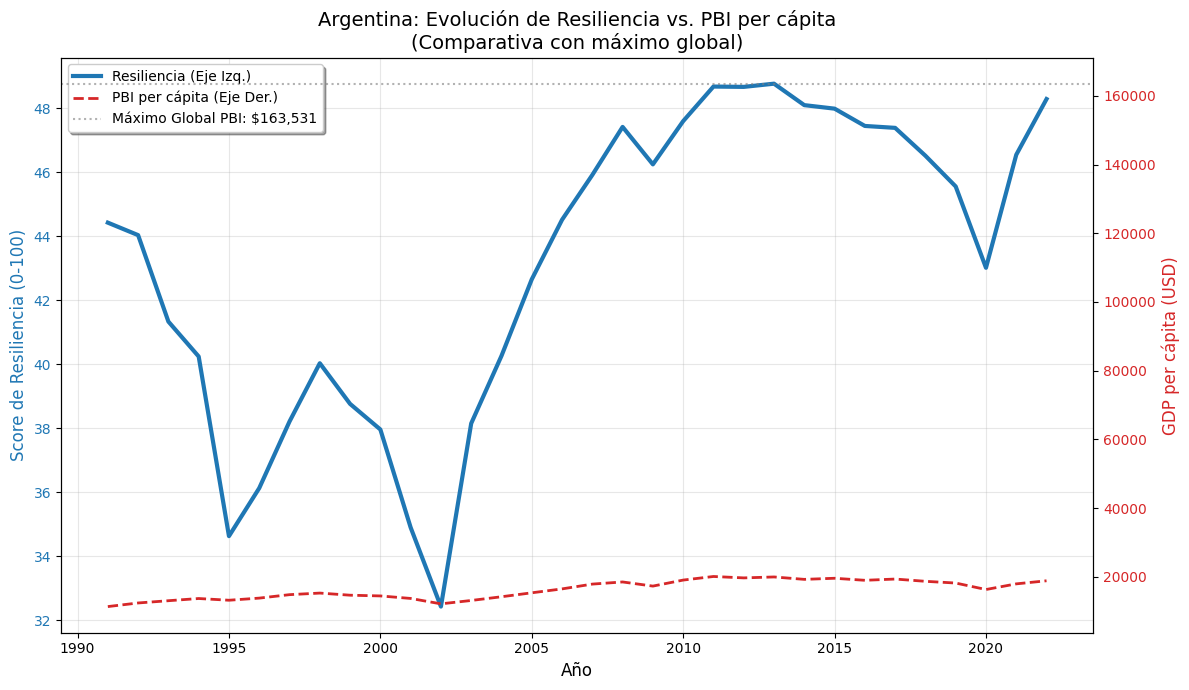

In [ ]:
import matplotlib.pyplot as plt

# Filtrar datos para Argentina y ordenar por año
df_arg = df[df['country'] == 'Argentina'].sort_values('year')
global_max_gdp = df['gdp_per_capita'].max()

fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje 1: Score de Resiliencia
color_res = 'tab:blue'
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Score de Resiliencia (0-100)', color=color_res, fontsize=12)
lns1 = ax1.plot(df_arg['year'], df_arg['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia (Eje Izq.)')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.grid(True, alpha=0.3)

# Eje 2: PBI per cápita
ax2 = ax1.twinx()
color_pbi = 'tab:red'
ax2.set_ylabel('GDP per cápita (USD)', color=color_pbi, fontsize=12)
lns2 = ax2.plot(df_arg['year'], df_arg['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita (Eje Der.)')

# Referencia del máximo global
lns3 = ax2.axhline(y=global_max_gdp, color='gray', linestyle=':', alpha=0.6, label=f'Máximo Global PBI: ${global_max_gdp:,.0f}')
ax2.tick_params(axis='y', labelcolor=color_pbi)

# Combinar leyendas
lns = lns1 + lns2 + [lns3]
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True, shadow=True)

plt.title('Argentina: Evolución de Resiliencia vs. PBI per cápita\n(Comparativa con máximo global)', fontsize=14)
fig.tight_layout()
plt.show()

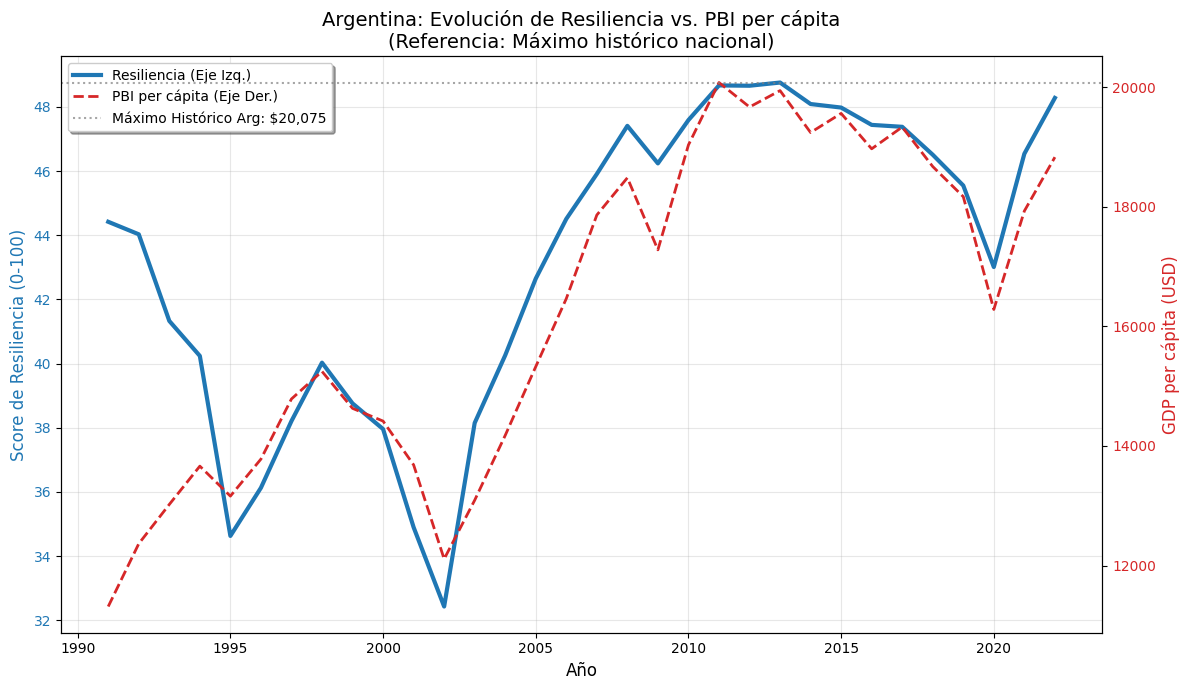

In [ ]:
import matplotlib.pyplot as plt

# Filtrar datos para Argentina y ordenar por año
df_arg = df[df['country'] == 'Argentina'].sort_values('year')

# Calcular el máximo histórico de PBI específicamente para Argentina
arg_max_gdp = df_arg['gdp_per_capita'].max()

fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje 1: Score de Resiliencia
color_res = 'tab:blue'
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Score de Resiliencia (0-100)', color=color_res, fontsize=12)
lns1 = ax1.plot(df_arg['year'], df_arg['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia (Eje Izq.)')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.grid(True, alpha=0.3)

# Eje 2: PBI per cápita
ax2 = ax1.twinx()
color_pbi = 'tab:red'
ax2.set_ylabel('GDP per cápita (USD)', color=color_pbi, fontsize=12)
lns2 = ax2.plot(df_arg['year'], df_arg['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita (Eje Der.)')

# Referencia del máximo HISTÓRICO DE ARGENTINA
lns3 = ax2.axhline(y=arg_max_gdp, color='gray', linestyle=':', alpha=0.7, label=f'Máximo Histórico Arg: ${arg_max_gdp:,.0f}')
ax2.tick_params(axis='y', labelcolor=color_pbi)

# Combinar leyendas
lns = lns1 + lns2 + [lns3]
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True, shadow=True)

plt.title('Argentina: Evolución de Resiliencia vs. PBI per cápita\n(Referencia: Máximo histórico nacional)', fontsize=14)
fig.tight_layout()
plt.show()

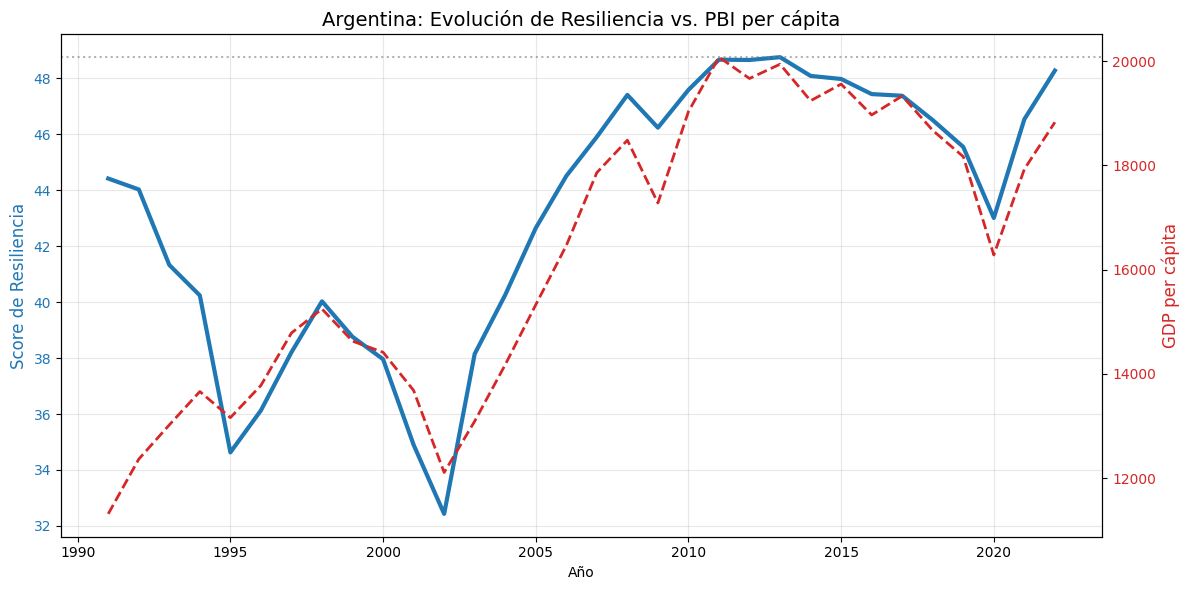

In [ ]:
import matplotlib.pyplot as plt

# Filtrar datos de Argentina
df_arg = df[df['country'] == 'Argentina'].sort_values('year')
arg_max_gdp = df_arg['gdp_per_capita'].max()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje de Resiliencia
color_res = 'tab:blue'
ax1.set_xlabel('Año')
ax1.set_ylabel('Score de Resiliencia', color=color_res, fontsize=12)
ax1.plot(df_arg['year'], df_arg['score_resiliencia'], color=color_res, linewidth=3, label='Resiliencia')
ax1.tick_params(axis='y', labelcolor=color_res)
ax1.grid(True, alpha=0.3)

# Eje de PBI
ax2 = ax1.twinx()
color_pbi = 'tab:red'
ax2.set_ylabel('GDP per cápita', color=color_pbi, fontsize=12)
ax2.plot(df_arg['year'], df_arg['gdp_per_capita'], color=color_pbi, linestyle='--', linewidth=2, label='PBI per cápita')
ax2.tick_params(axis='y', labelcolor=color_pbi)

# Línea de referencia del máximo nacional
ax2.axhline(y=arg_max_gdp, color='gray', linestyle=':', alpha=0.6, label=f'Máximo Arg: ${arg_max_gdp:,.0f}')

plt.title('Argentina: Evolución de Resiliencia vs. PBI per cápita', fontsize=14)
fig.tight_layout()
plt.show()

### Análisis Histórico: Países de la ex-Yugoslavia
En esta sección analizamos la evolución del Índice de Resiliencia para las naciones que conformaron Yugoslavia, permitiendo comparar sus trayectorias de recuperación y estabilidad.

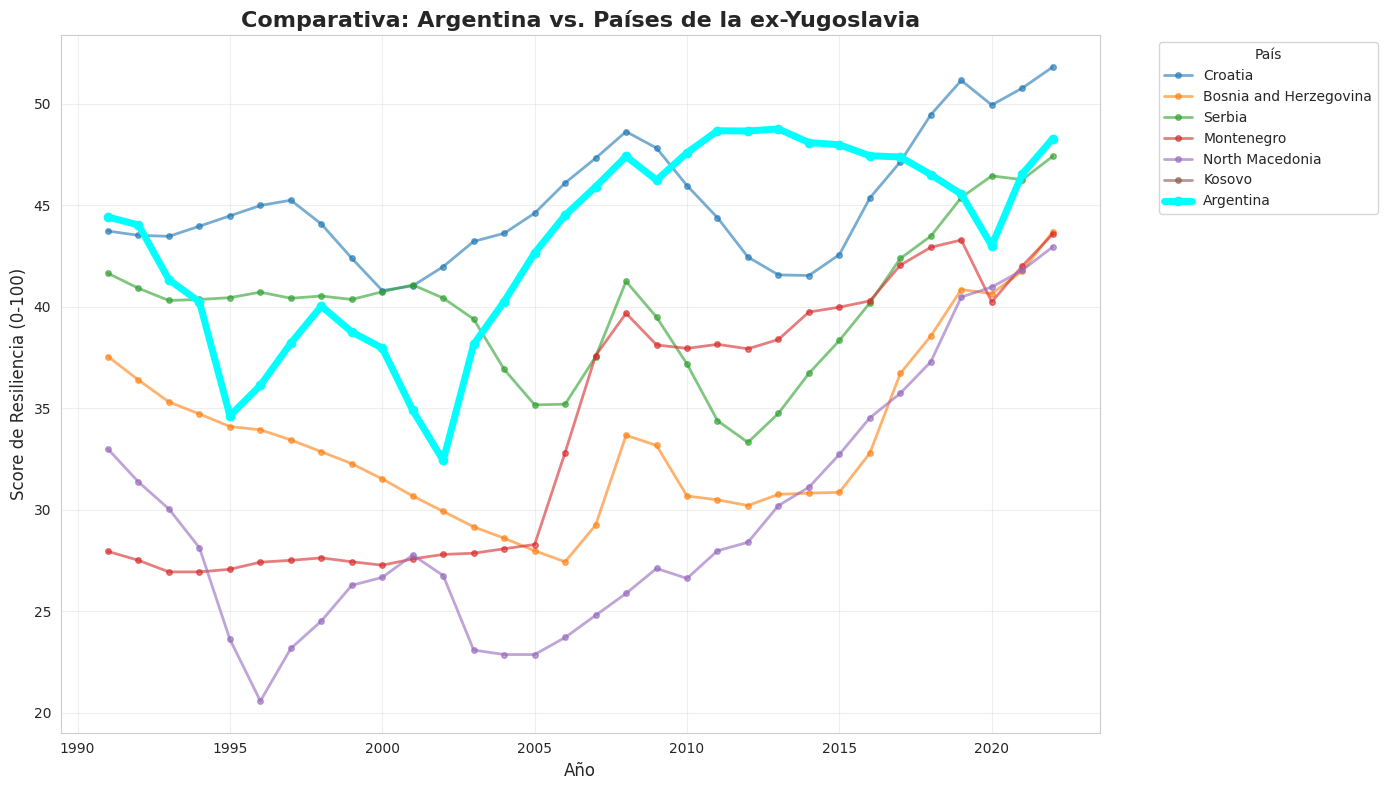

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de países solicitada (ex-Yugoslavia sin Eslovenia + Argentina)
paises_analisis = [
    'Croatia', 'Bosnia and Herzegovina', 'Serbia',
    'Montenegro', 'North Macedonia', 'Kosovo', 'Argentina'
]

# Filtrar el DataFrame
df_comp = df[df['country'].isin(paises_analisis)].sort_values(['country', 'year'])

# Configuración del gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Definir paleta: Argentina destacada, el resto en tonos grises/atenuados
# O usamos un color llamativo para Argentina
colores = {}
for p in paises_analisis:
    if p == 'Argentina':
        colores[p] = '#00FFFF' # Cyan brillante para destacar
    else:
        colores[p] = None # Dejar que seaborn asigne el resto

# Dibujar líneas
for pais in paises_analisis:
    data_p = df_comp[df_comp['country'] == pais]
    linewidth = 5 if pais == 'Argentina' else 2
    zorder = 10 if pais == 'Argentina' else 2
    alpha = 1.0 if pais == 'Argentina' else 0.6

    plt.plot(data_p['year'], data_p['score_resiliencia'],
             label=pais, linewidth=linewidth, zorder=zorder, alpha=alpha,
             marker='o', markersize=4 if pais != 'Argentina' else 6,
             color=colores[pais])

# Personalización
plt.title('Comparativa: Argentina vs. Países de la ex-Yugoslavia', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Score de Resiliencia (0-100)', fontsize=12)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Como podemos observar, países como **Eslovenia** suelen liderar la región debido a su temprana integración económica y estabilidad laboral, mientras que otros como **Macedonia del Norte** muestran los niveles históricos más bajos en los registros de la década de los 90.

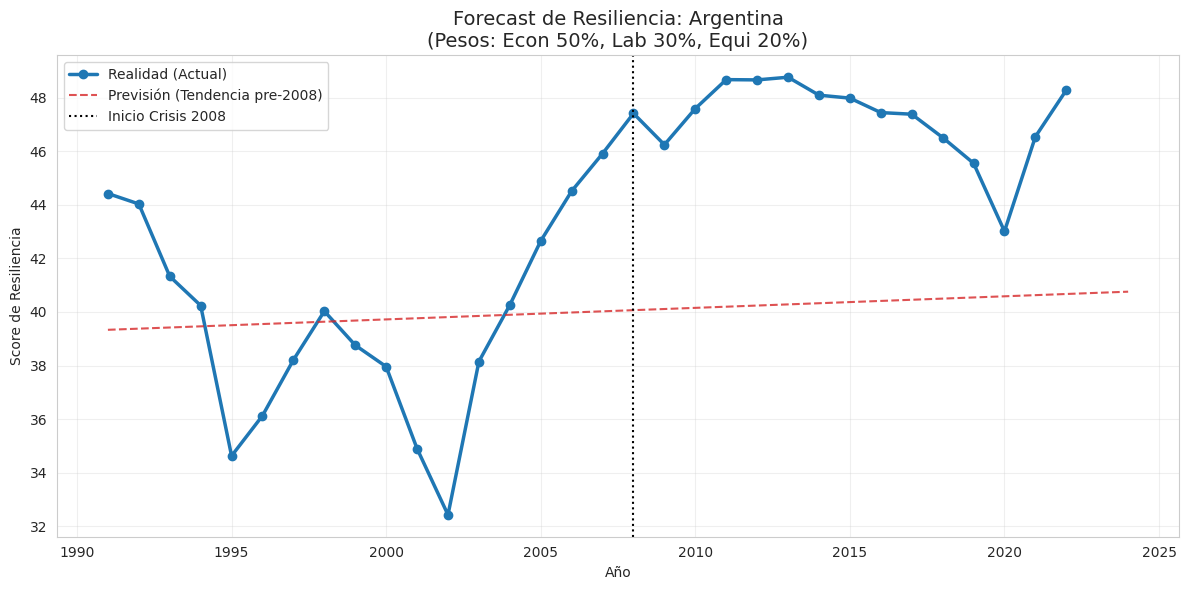

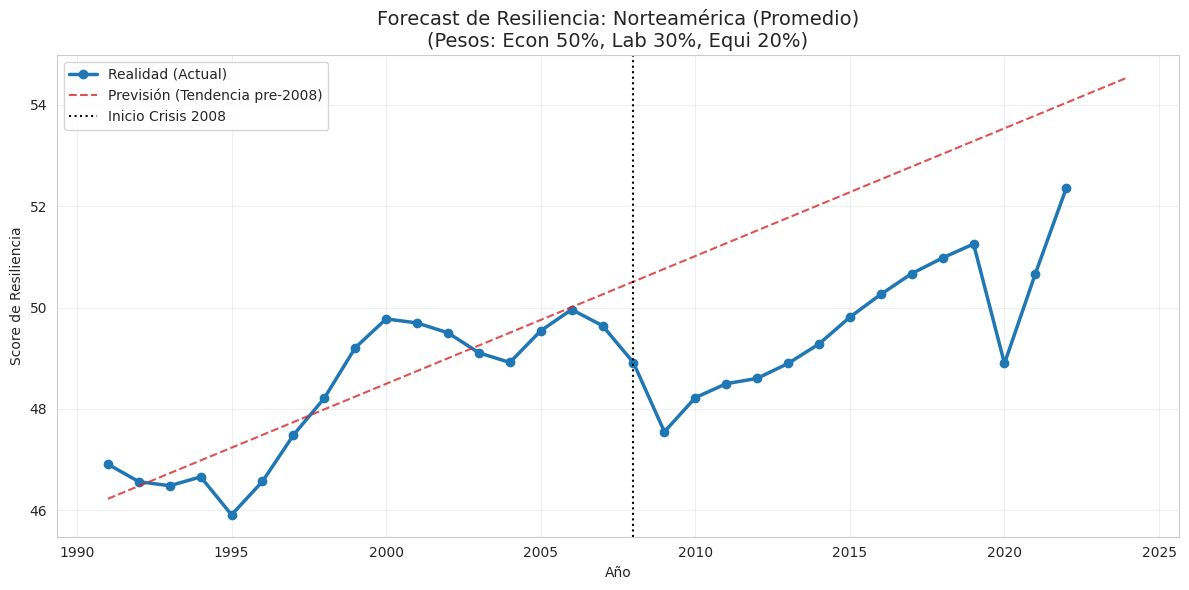

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Confirmamos los pesos solicitados para el Score de Resiliencia
PESO_ECONOMICO = 0.50
PESO_LABORAL = 0.30
PESO_EQUIDAD = 0.20

# Definición de regiones
norteamerica = ['United States', 'Canada', 'Mexico']

def analyze_recovery(country_list, name):
    # Agrupar datos por año para la región/país
    df_reg = df[df['country'].isin(country_list)].groupby('year')['score_resiliencia'].mean().reset_index()

    # Datos previos a la crisis (hasta 2007) para entrenar la tendencia
    df_pre = df_reg[df_reg['year'] <= 2007]

    if df_pre.empty:
        print(f"No hay suficientes datos pre-2008 para {name}")
        return

    # Entrenar modelo de regresión lineal con la tendencia pre-crisis
    model = LinearRegression()
    X_pre = df_pre[['year']]
    y_pre = df_pre['score_resiliencia']
    model.fit(X_pre, y_pre)

    # Generar el Forecast (proyección) para todo el periodo
    df_reg['forecast'] = model.predict(df_reg[['year']])

    # Visualización
    plt.figure(figsize=(12, 6))
    plt.plot(df_reg['year'], df_reg['score_resiliencia'], label='Realidad (Actual)', marker='o', linewidth=2.5, color='#1f77b4')
    plt.plot(df_reg['year'], df_reg['forecast'], label='Previsión (Tendencia pre-2008)', linestyle='--', color='#d62728', alpha=0.8)

    # Marcador de la crisis
    plt.axvline(x=2008, color='black', linestyle=':', label='Inicio Crisis 2008')

    plt.title(f'Forecast de Resiliencia: {name}\n(Pesos: Econ 50%, Lab 30%, Equi 20%)', fontsize=14)
    plt.xlabel('Año')
    plt.ylabel('Score de Resiliencia')
    plt.legend(frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Ejecutar análisis para Argentina y Norteamérica
analyze_recovery(['Argentina'], 'Argentina')
analyze_recovery(norteamerica, 'Norteamérica (Promedio)')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


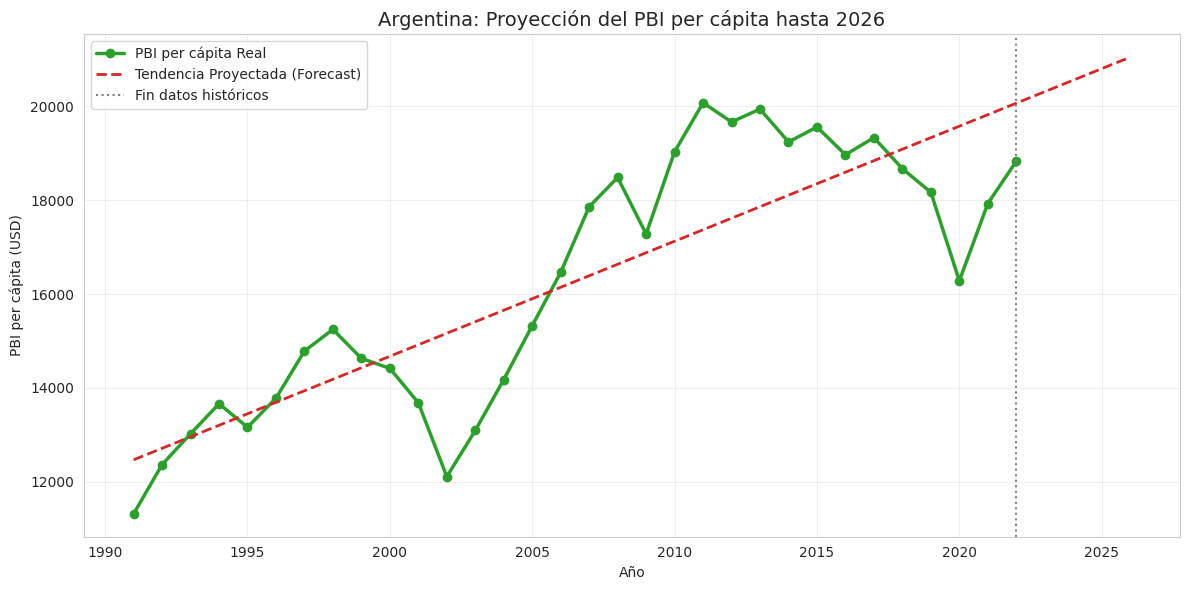

Valores proyectados del PBI per cápita para Argentina:
Año 2024: $20,555.80 USD
Año 2025: $20,800.86 USD
Año 2026: $21,045.92 USD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparar datos de PBI per cápita para Argentina
df_arg_gdp = df[df['country'] == 'Argentina'].dropna(subset=['gdp_per_capita']).sort_values('year')

# 2. Entrenar el modelo con la tendencia histórica
X_gdp = df_arg_gdp[['year']]
y_gdp = df_arg_gdp['gdp_per_capita']

model_gdp_final = LinearRegression()
model_gdp_final.fit(X_gdp, y_gdp)

# 3. Generar Previsión hasta 2026
years_range = np.arange(1991, 2027).reshape(-1, 1)
gdp_forecast_final = model_gdp_final.predict(years_range)

# 4. Visualización
plt.figure(figsize=(12, 6))

# Realidad
plt.plot(df_arg_gdp['year'], df_arg_gdp['gdp_per_capita'], label='PBI per cápita Real', color='#2ca02c', marker='o', linewidth=2.5)

# Previsión
plt.plot(years_range, gdp_forecast_final, label='Tendencia Proyectada (Forecast)', color='#d62728', linestyle='--', linewidth=2)

plt.title('Argentina: Proyección del PBI per cápita hasta 2026', fontsize=14)
plt.xlabel('Año')
plt.ylabel('PBI per cápita (USD)')
plt.axvline(x=2022, color='gray', linestyle=':', label='Fin datos históricos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Resultados numéricos específicos para el usuario
future_years_list = [2024, 2025, 2026]
future_preds = model_gdp_final.predict(np.array(future_years_list).reshape(-1, 1))

print("Valores proyectados del PBI per cápita para Argentina:")
for yr, val in zip(future_years_list, future_preds):
    print(f"Año {yr}: ${val:,.2f} USD")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


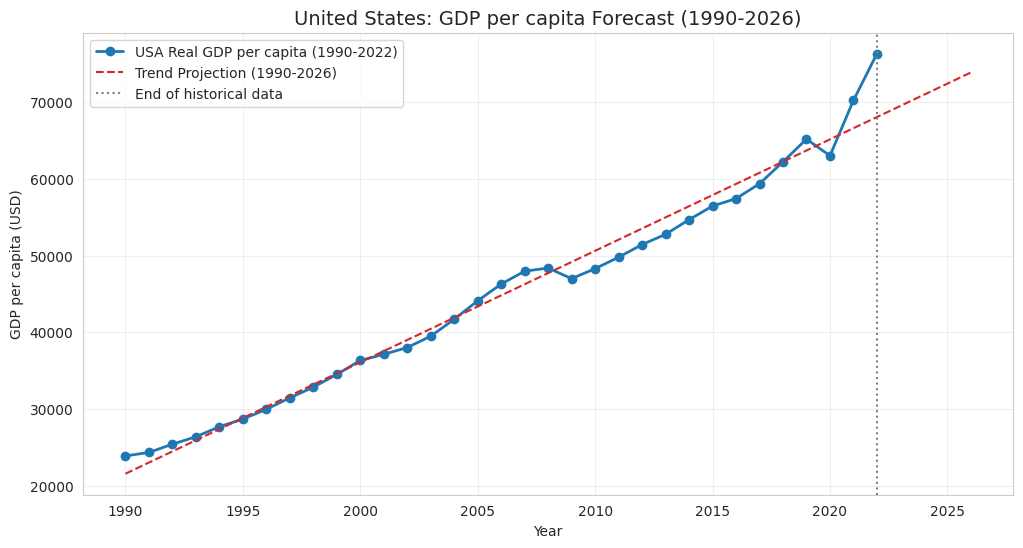

Projected GDP per capita for USA (Model based on 1990-2022 trend):
Year 2024: $70,977.66 USD
Year 2025: $72,430.91 USD
Year 2026: $73,884.15 USD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd

# 1. Manually providing USA historical data from 1990 to 2022 (World Bank approximate values)
usa_historical_data = {
    'year': list(range(1990, 2023)),
    'gdp_per_capita': [
        23888, 24342, 25418, 26387, 27694, 28690, 29967, 31459, 32853, 34513,
        36334, 37133, 38023, 39496, 41712, 44114, 46298, 47975, 48382, 47001,
        48311, 49793, 51450, 52782, 54696, 56469, 57436, 59382, 62232, 65202,
        63027, 70248, 76329
    ]
}
df_usa = pd.DataFrame(usa_historical_data)

# 2. Train the model using the 1990-2022 range
X_usa = df_usa[['year']]
y_usa = df_usa['gdp_per_capita']
model_usa = LinearRegression()
model_usa.fit(X_usa, y_usa)

# 3. Forecast from 1990 until 2026
years_range = np.arange(1990, 2027).reshape(-1, 1)
forecast_values = model_usa.predict(years_range)

# 4. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_usa['year'], df_usa['gdp_per_capita'], label='USA Real GDP per capita (1990-2022)', marker='o', color='#1f77b4', linewidth=2)
plt.plot(years_range, forecast_values, label='Trend Projection (1990-2026)', linestyle='--', color='#d62728')

plt.title('United States: GDP per capita Forecast (1990-2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('GDP per capita (USD)')
plt.axvline(x=2022, color='gray', linestyle=':', label='End of historical data')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 5. Numerical Results for the requested forecast period
future_years = np.array([2024, 2025, 2026]).reshape(-1, 1)
preds = model_usa.predict(future_years)

print("Projected GDP per capita for USA (Model based on 1990-2022 trend):")
for yr, val in zip([2024, 2025, 2026], preds):
    print(f"Year {yr}: ${val:,.2f} USD")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


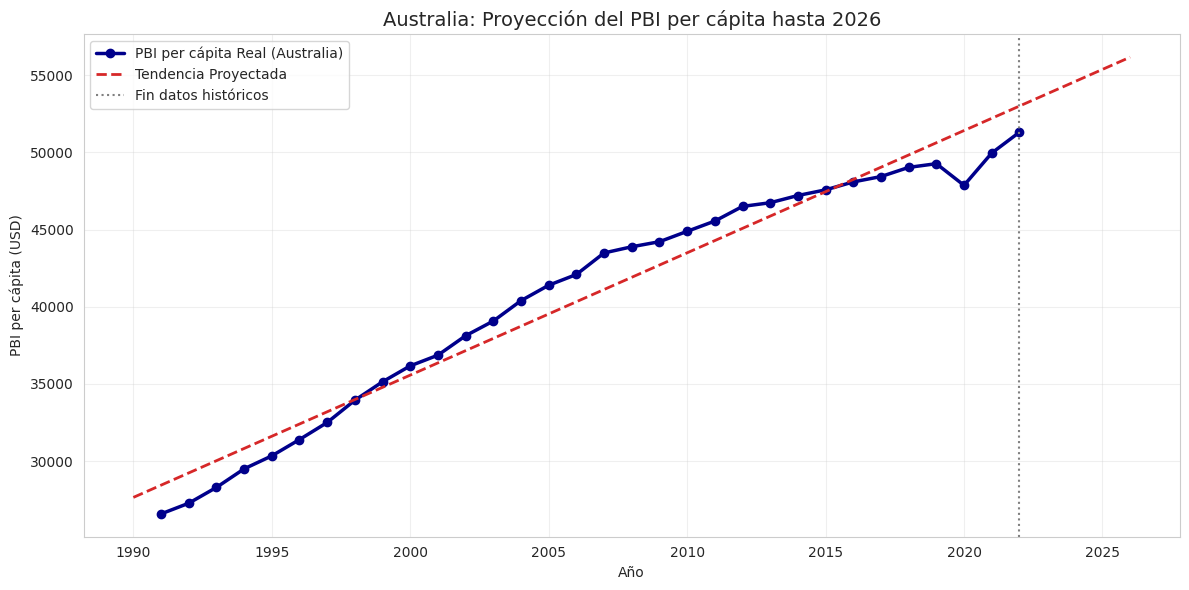

Valores proyectados del PBI per cápita para Australia (basado en tendencia 1990-2022):
Año 2024: $54,584.45 USD
Año 2025: $55,376.59 USD
Año 2026: $56,168.73 USD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparar datos de PBI per cápita para Australia
df_aus_gdp = df[df['country'] == 'Australia'].dropna(subset=['gdp_per_capita']).sort_values('year')

# 2. Entrenar el modelo con la tendencia histórica (1990-2022)
X_aus = df_aus_gdp[['year']]
y_aus = df_aus_gdp['gdp_per_capita']

model_aus = LinearRegression()
model_aus.fit(X_aus, y_aus)

# 3. Generar Previsión hasta 2026
years_range_aus = np.arange(1990, 2027).reshape(-1, 1)
aus_forecast_plot = model_aus.predict(years_range_aus)

# 4. Visualización
plt.figure(figsize=(12, 6))
plt.plot(df_aus_gdp['year'], df_aus_gdp['gdp_per_capita'], label='PBI per cápita Real (Australia)', color='#00008B', marker='o', linewidth=2.5)
plt.plot(years_range_aus, aus_forecast_plot, label='Tendencia Proyectada', color='#d62728', linestyle='--', linewidth=2)

plt.title('Australia: Proyección del PBI per cápita hasta 2026', fontsize=14)
plt.xlabel('Año')
plt.ylabel('PBI per cápita (USD)')
plt.axvline(x=2022, color='gray', linestyle=':', label='Fin datos históricos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Resultados numéricos
future_years = np.array([2024, 2025, 2026]).reshape(-1, 1)
aus_preds = model_aus.predict(future_years)

print("Valores proyectados del PBI per cápita para Australia (basado en tendencia 1990-2022):")
for yr, val in zip([2024, 2025, 2026], aus_preds):
    print(f"Año {yr}: ${val:,.2f} USD")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


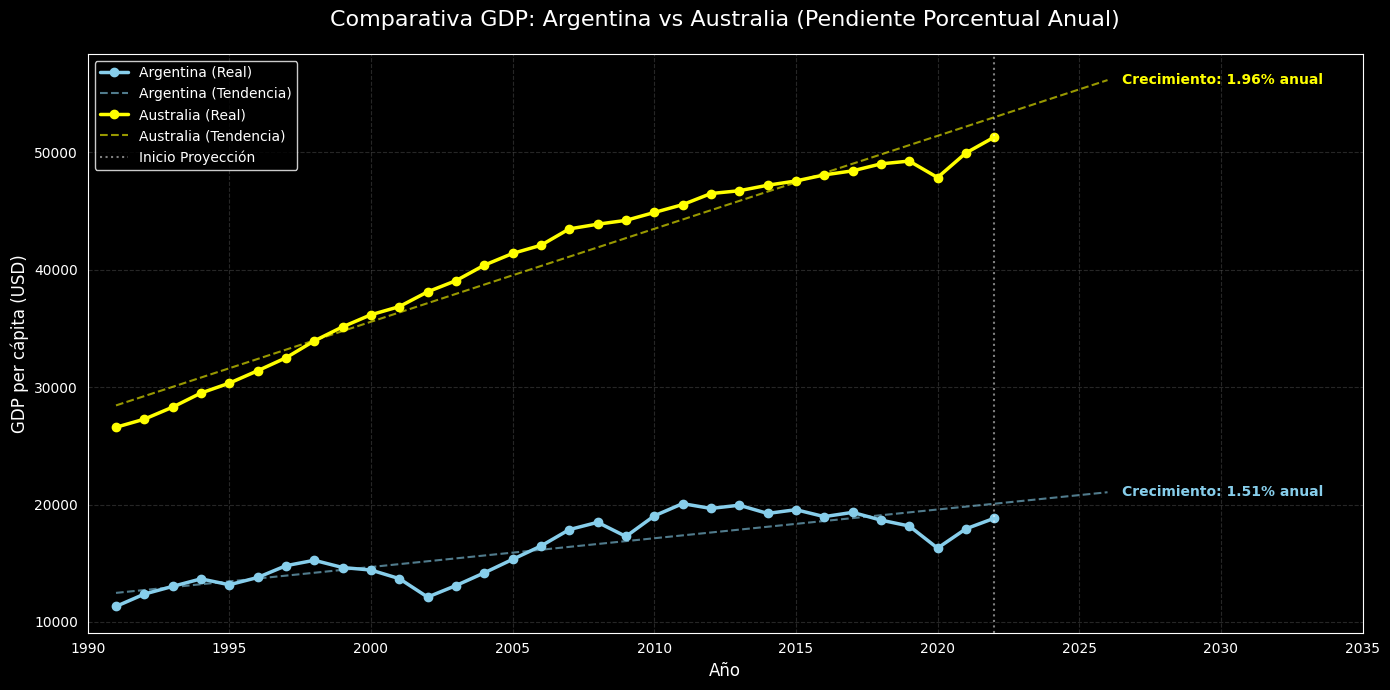

Análisis de Crecimiento Tendencial Porcentual (CAGR 1991-2026):
🇦🇷 Argentina: 1.51% anual
🇦🇺 Australia: 1.96% anual


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Configurar el estilo de fondo negro
plt.style.use('dark_background')

# 1. Preparar datos para Argentina
df_arg = df[df['country'] == 'Argentina'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_arg = df_arg[['year']]
y_arg = df_arg['gdp_per_capita']
model_arg = LinearRegression().fit(X_arg, y_arg)

# 2. Preparar datos para Australia
df_aus = df[df['country'] == 'Australia'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_aus = df_aus[['year']]
y_aus = df_aus['gdp_per_capita']
model_aus = LinearRegression().fit(X_aus, y_aus)

# 3. Generar Rango de años y predicciones
years_full = np.arange(1991, 2027).reshape(-1, 1)
pred_arg = model_arg.predict(years_full)
pred_aus = model_aus.predict(years_full)

# 4. Calcular Pendiente Porcentual (CAGR de la tendencia)
def calculate_cagr(start_val, end_val, periods):
    return (pow(end_val / start_val, 1 / periods) - 1) * 100

cagr_arg = calculate_cagr(pred_arg[0], pred_arg[-1], len(years_full)-1)
cagr_aus = calculate_cagr(pred_aus[0], pred_aus[-1], len(years_full)-1)

# 5. Gráfico Comparativo
plt.figure(figsize=(14, 7))

# Argentina: Celeste
plt.plot(df_arg['year'], df_arg['gdp_per_capita'], color='#87CEEB', marker='o', label='Argentina (Real)', linewidth=2.5)
plt.plot(years_full, pred_arg, color='#87CEEB', linestyle='--', alpha=0.6, label='Argentina (Tendencia)')

# Australia: Amarillo
plt.plot(df_aus['year'], df_aus['gdp_per_capita'], color='#FFFF00', marker='o', label='Australia (Real)', linewidth=2.5)
plt.plot(years_full, pred_aus, color='#FFFF00', linestyle='--', alpha=0.6, label='Australia (Tendencia)')

# 6. Agregar pendientes porcentuales al final de las líneas
plt.text(2026.5, pred_arg[-1], f'Crecimiento: {cagr_arg:.2f}% anual', color='#87CEEB', va='center', fontweight='bold')
plt.text(2026.5, pred_aus[-1], f'Crecimiento: {cagr_aus:.2f}% anual', color='#FFFF00', va='center', fontweight='bold')

# Detalles estéticos
plt.axvline(x=2022, color='white', linestyle=':', alpha=0.5, label='Inicio Proyección')
plt.title('Comparativa GDP: Argentina vs Australia (Pendiente Porcentual Anual)', fontsize=16, color='white', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('GDP per cápita (USD)', fontsize=12)
plt.legend(facecolor='black', edgecolor='white', loc='upper left')
plt.grid(True, color='gray', linestyle='--', alpha=0.3)

plt.xlim(1990, 2035)
plt.tight_layout()
plt.show()

# Resultados numéricos
print(f"Análisis de Crecimiento Tendencial Porcentual (CAGR 1991-2026):")
print(f"🇦🇷 Argentina: {cagr_arg:.2f}% anual")
print(f"🇦🇺 Australia: {cagr_aus:.2f}% anual")

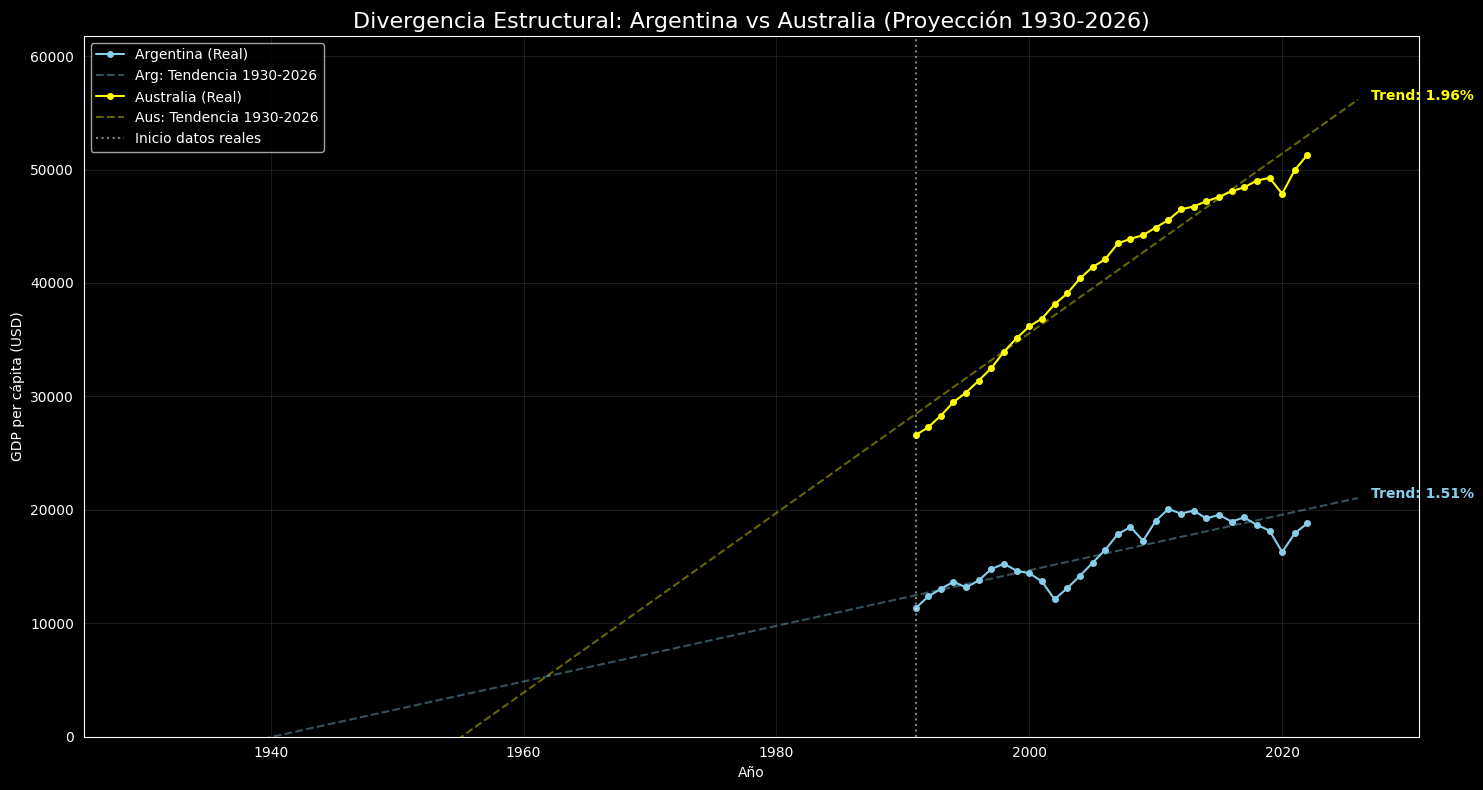

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Preparar datos y entrenar modelos con nombres de columnas consistentes
df_arg = df[df['country'] == 'Argentina'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_arg = df_arg[['year']]
y_arg = df_arg['gdp_per_capita']
model_arg = LinearRegression().fit(X_arg, y_arg)

df_aus = df[df['country'] == 'Australia'].dropna(subset=['gdp_per_capita']).sort_values('year')
X_aus = df_aus[['year']]
y_aus = df_aus['gdp_per_capita']
model_aus = LinearRegression().fit(X_aus, y_aus)

# 2. Rango extendido para visualización (1930-2026)
years_ext = pd.DataFrame({'year': np.arange(1930, 2027)})
pred_arg_ext = model_arg.predict(years_ext)
pred_aus_ext = model_aus.predict(years_ext)

# 3. CAGR (Calculado sobre el periodo con datos positivos: 1991-2026)
def calc_cagr(start, end, p):
    if start <= 0: return 0
    return (pow(end / start, 1/p) - 1) * 100

# Predicciones puntuales usando DataFrames para evitar warnings de feature names
val_1991_arg = model_arg.predict(pd.DataFrame({'year': [1991]}))[0]
val_2026_arg = model_arg.predict(pd.DataFrame({'year': [2026]}))[0]
val_1991_aus = model_aus.predict(pd.DataFrame({'year': [1991]}))[0]
val_2026_aus = model_aus.predict(pd.DataFrame({'year': [2026]}))[0]

cagr_arg = calc_cagr(val_1991_arg, val_2026_arg, 2026-1991)
cagr_aus = calc_cagr(val_1991_aus, val_2026_aus, 2026-1991)

# 4. Gráfico con estética Dark
plt.style.use('dark_background')
plt.figure(figsize=(15, 8))

# Argentina (Celeste)
plt.plot(df_arg['year'], df_arg['gdp_per_capita'], color='#87CEEB', marker='o', label='Argentina (Real)', markersize=4)
plt.plot(years_ext['year'], pred_arg_ext, color='#87CEEB', linestyle='--', alpha=0.4, label='Arg: Tendencia 1930-2026')

# Australia (Amarillo)
plt.plot(df_aus['year'], df_aus['gdp_per_capita'], color='#FFFF00', marker='o', label='Australia (Real)', markersize=4)
plt.plot(years_ext['year'], pred_aus_ext, color='#FFFF00', linestyle='--', alpha=0.4, label='Aus: Tendencia 1930-2026')

# Limitar eje Y para evitar valores negativos de la regresión lineal
plt.ylim(0, max(pred_aus_ext) * 1.1)

# Anotaciones de Crecimiento
plt.text(2027, pred_arg_ext[-1], f'Trend: {cagr_arg:.2f}%', color='#87CEEB', fontweight='bold')
plt.text(2027, pred_aus_ext[-1], f'Trend: {cagr_aus:.2f}%', color='#FFFF00', fontweight='bold')

plt.axvline(x=1991, color='white', linestyle=':', alpha=0.5, label='Inicio datos reales')
plt.title('Divergencia Estructural: Argentina vs Australia (Proyección 1930-2026)', fontsize=16)
plt.ylabel('GDP per cápita (USD)')
plt.xlabel('Año')
plt.legend(loc='upper left', frameon=True, facecolor='black')
plt.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

In [3]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# ✅ CARGAR DATOS (esto soluciona el error)
df = px.data.gapminder()

# Renombrar columnas para que coincidan con tu código
df = df.rename(columns={
    'gdpPercap': 'gdp_per_capita'
})

# Filtrar solo países necesarios
df = df[df['country'].isin(['Argentina', 'Australia'])]

# 1. Preparar datos
df_arg = df[df['country'] == 'Argentina'].dropna(subset=['gdp_per_capita']).sort_values('year')
df_aus = df[df['country'] == 'Australia'].dropna(subset=['gdp_per_capita']).sort_values('year')

X_arg = df_arg[['year']]
y_arg = df_arg['gdp_per_capita']
model_arg = LinearRegression().fit(X_arg, y_arg)

X_aus = df_aus[['year']]
y_aus = df_aus['gdp_per_capita']
model_aus = LinearRegression().fit(X_aus, y_aus)

# 2. Proyección
years_ext = pd.DataFrame({'year': np.arange(1950, 2030)})
pred_arg_ext = model_arg.predict(years_ext)
pred_aus_ext = model_aus.predict(years_ext)

# 3. CAGR
def calc_cagr(start, end, p):
    if start <= 0: return 0
    return (pow(end / start, 1/p) - 1) * 100

val_1991_arg = model_arg.predict(pd.DataFrame({'year': [1991]}))[0]
val_2026_arg = model_arg.predict(pd.DataFrame({'year': [2026]}))[0]
val_1991_aus = model_aus.predict(pd.DataFrame({'year': [1991]}))[0]
val_2026_aus = model_aus.predict(pd.DataFrame({'year': [2026]}))[0]

cagr_arg = calc_cagr(val_1991_arg, val_2026_arg, 2026-1991)
cagr_aus = calc_cagr(val_1991_aus, val_2026_aus, 2026-1991)

# 4. Gráfico interactivo
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_arg['year'],
    y=df_arg['gdp_per_capita'],
    mode='lines+markers',
    name='Argentina (Real)',
    line=dict(color='#87CEEB')
))

fig.add_trace(go.Scatter(
    x=years_ext['year'],
    y=pred_arg_ext,
    mode='lines',
    name='Arg: Tendencia',
    line=dict(color='#87CEEB', dash='dash'),
    opacity=0.5
))

fig.add_trace(go.Scatter(
    x=df_aus['year'],
    y=df_aus['gdp_per_capita'],
    mode='lines+markers',
    name='Australia (Real)',
    line=dict(color='#FFFF00')
))

fig.add_trace(go.Scatter(
    x=years_ext['year'],
    y=pred_aus_ext,
    mode='lines',
    name='Aus: Tendencia',
    line=dict(color='#FFFF00', dash='dash'),
    opacity=0.5
))

# Línea vertical
fig.add_vline(x=1991, line=dict(color='white', dash='dot'))

# Estilo
fig.update_layout(
    title="Divergencia: Argentina vs Australia",
    xaxis_title="Año",
    yaxis_title="GDP per cápita (USD)",
    template="plotly_dark"
)

# Anotaciones
fig.add_annotation(x=2026, y=pred_arg_ext[-1],
                   text=f"Arg: {cagr_arg:.2f}%",
                   showarrow=False,
                   font=dict(color='#87CEEB'))

fig.add_annotation(x=2026, y=pred_aus_ext[-1],
                   text=f"Aus: {cagr_aus:.2f}%",
                   showarrow=False,
                   font=dict(color='#FFFF00'))

fig.show()

# ✅ EXPORTAR PARA CANVA
fig.write_html("grafico_interactivo.html")


In [5]:
fig.write_html("grafico_interactivo.html")

In [7]:
from google.colab import files
files.download("grafico_interactivo.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>